In [1]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_score, recall_score, accuracy_score
from matplotlib_venn import venn2
from read_predictions import get_all_predictions

plt.style.use('ggplot')
# Global styling tweaks
mpl.rcParams.update({
    'axes.facecolor': 'white',
    'axes.labelcolor': 'black',
    'axes.labelsize': 11,
    'xtick.color': 'black',
    'xtick.labelsize': 11,
    'ytick.color': 'black',
    'ytick.labelsize': 11,
    'grid.linestyle': '--',
    'grid.color': 'black',
    'grid.alpha': 0.5,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'savefig.dpi': 300,
    'figure.dpi': 100
})
def style_ax(ax):
    ax.spines['bottom'].set_color('black')
    ax.spines['left'].set_color('black')
    ax.grid(True, linestyle='--', alpha=0.5, color='black', axis='y')



In [ ]:
all_predictions = get_all_predictions()
all_predictions


## Get the prediction score metrics

In [3]:
def bootstrap_ci(series_true, series_pred, metric_fn, n_bootstraps=1000, ci=95):
    """Return (point_estimate, lower_bound, upper_bound) for the metric via bootstrapping."""
    # point estimate on full sample:
    point = metric_fn(series_true, series_pred)
    bootstraps = []
    n = len(series_true)
    for _ in range(n_bootstraps):
        idx = np.random.randint(0, n, n)
        y_true_bs = series_true.iloc[idx]
        y_pred_bs = series_pred.iloc[idx]
        bootstraps.append(metric_fn(y_true_bs, y_pred_bs))
    lower = np.percentile(bootstraps, (100 - ci) / 2)
    upper = np.percentile(bootstraps, 100 - (100 - ci) / 2)
    return point, lower, upper

In [4]:
result_scores = []
POS = "fail"

for weighting in all_predictions['balanced'].unique():
    for test_set in all_predictions['samples'].unique():
        results = []
        dataset = all_predictions[(all_predictions['samples'] == test_set) & (all_predictions['balanced'] == weighting)]
        if test_set == 'all':
            dataset = dataset[dataset['original_set'] == 'test']
        for model_name, grp in dataset.groupby('model'):
            y_true = (grp['true'] == POS).astype(int)
            y_pred = (grp['pred'] == POS).astype(int)
            # compute sensitivity (recall) CI
            sens, sens_lo, sens_hi = bootstrap_ci(y_true, y_pred,lambda t, p: recall_score(t, p),n_bootstraps=500, ci=95)
            # compute precision CI
            prec, prec_lo, prec_hi = bootstrap_ci(y_true, y_pred, lambda t, p: precision_score(t, p, zero_division=0), n_bootstraps=500, ci=95)
            
            results.append({
                'model': model_name,
                'sensitivity': sens, 'sens_lo': sens_lo, 'sens_hi': sens_hi,
                'precision':    prec, 'prec_lo':  prec_lo, 'prec_hi':  prec_hi
            })

            res_df = pd.DataFrame(results).sort_values('model')
            res_df['dataset'] = "patient set" if test_set == 'patients' else "validation set"
            res_df['balanced'] = "weighted" if weighting else "unweighted"
            result_scores.append(res_df)
result_scores = pd.concat(result_scores, ignore_index=True)

/home/elias/.conda/envs/ProBone/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/elias/.conda/envs/ProBone/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/elias/.conda/envs/ProBone/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/elias/.conda/envs/ProBone/li

In [5]:
result_scores

,model,sensitivity,sens_lo,sens_hi,precision,prec_lo,prec_hi,dataset,balanced
0,Radius XCT1,0.711111,0.621608,0.802265,0.853333,0.782229,0.924836,validation set,unweighted
1,Radius XCT1,0.711111,0.621608,0.802265,0.853333,0.782229,0.924836,validation set,unweighted
2,Radius XCT2,0.387097,0.218037,0.569595,0.631579,0.391923,0.848173,validation set,unweighted
3,Radius XCT1,0.711111,0.621608,0.802265,0.853333,0.782229,0.924836,validation set,unweighted
4,Radius XCT2,0.387097,0.218037,0.569595,0.631579,0.391923,0.848173,validation set,unweighted
5,Tibia XCT1,0.235294,0.000000,0.452386,1.000000,1.000000,1.000000,validation set,unweighted
6,Radius XCT1,0.711111,0.621608,0.802265,0.853333,0.782229,0.924836,validation set,unweighted
7,Radius XCT2,0.387097,0.218037,0.569595,0.631579,0.391923,0.848173,validation set,unweighted
8,Tibia XCT1,0.235294,0.000000,0.452386,1.000000,1.000000,1.000000,validation set,unweighted
9,Tibia XCT2,0.363636,0.027941,0.666667,0.800000,0.333333,1.000000,validation set,unweighted


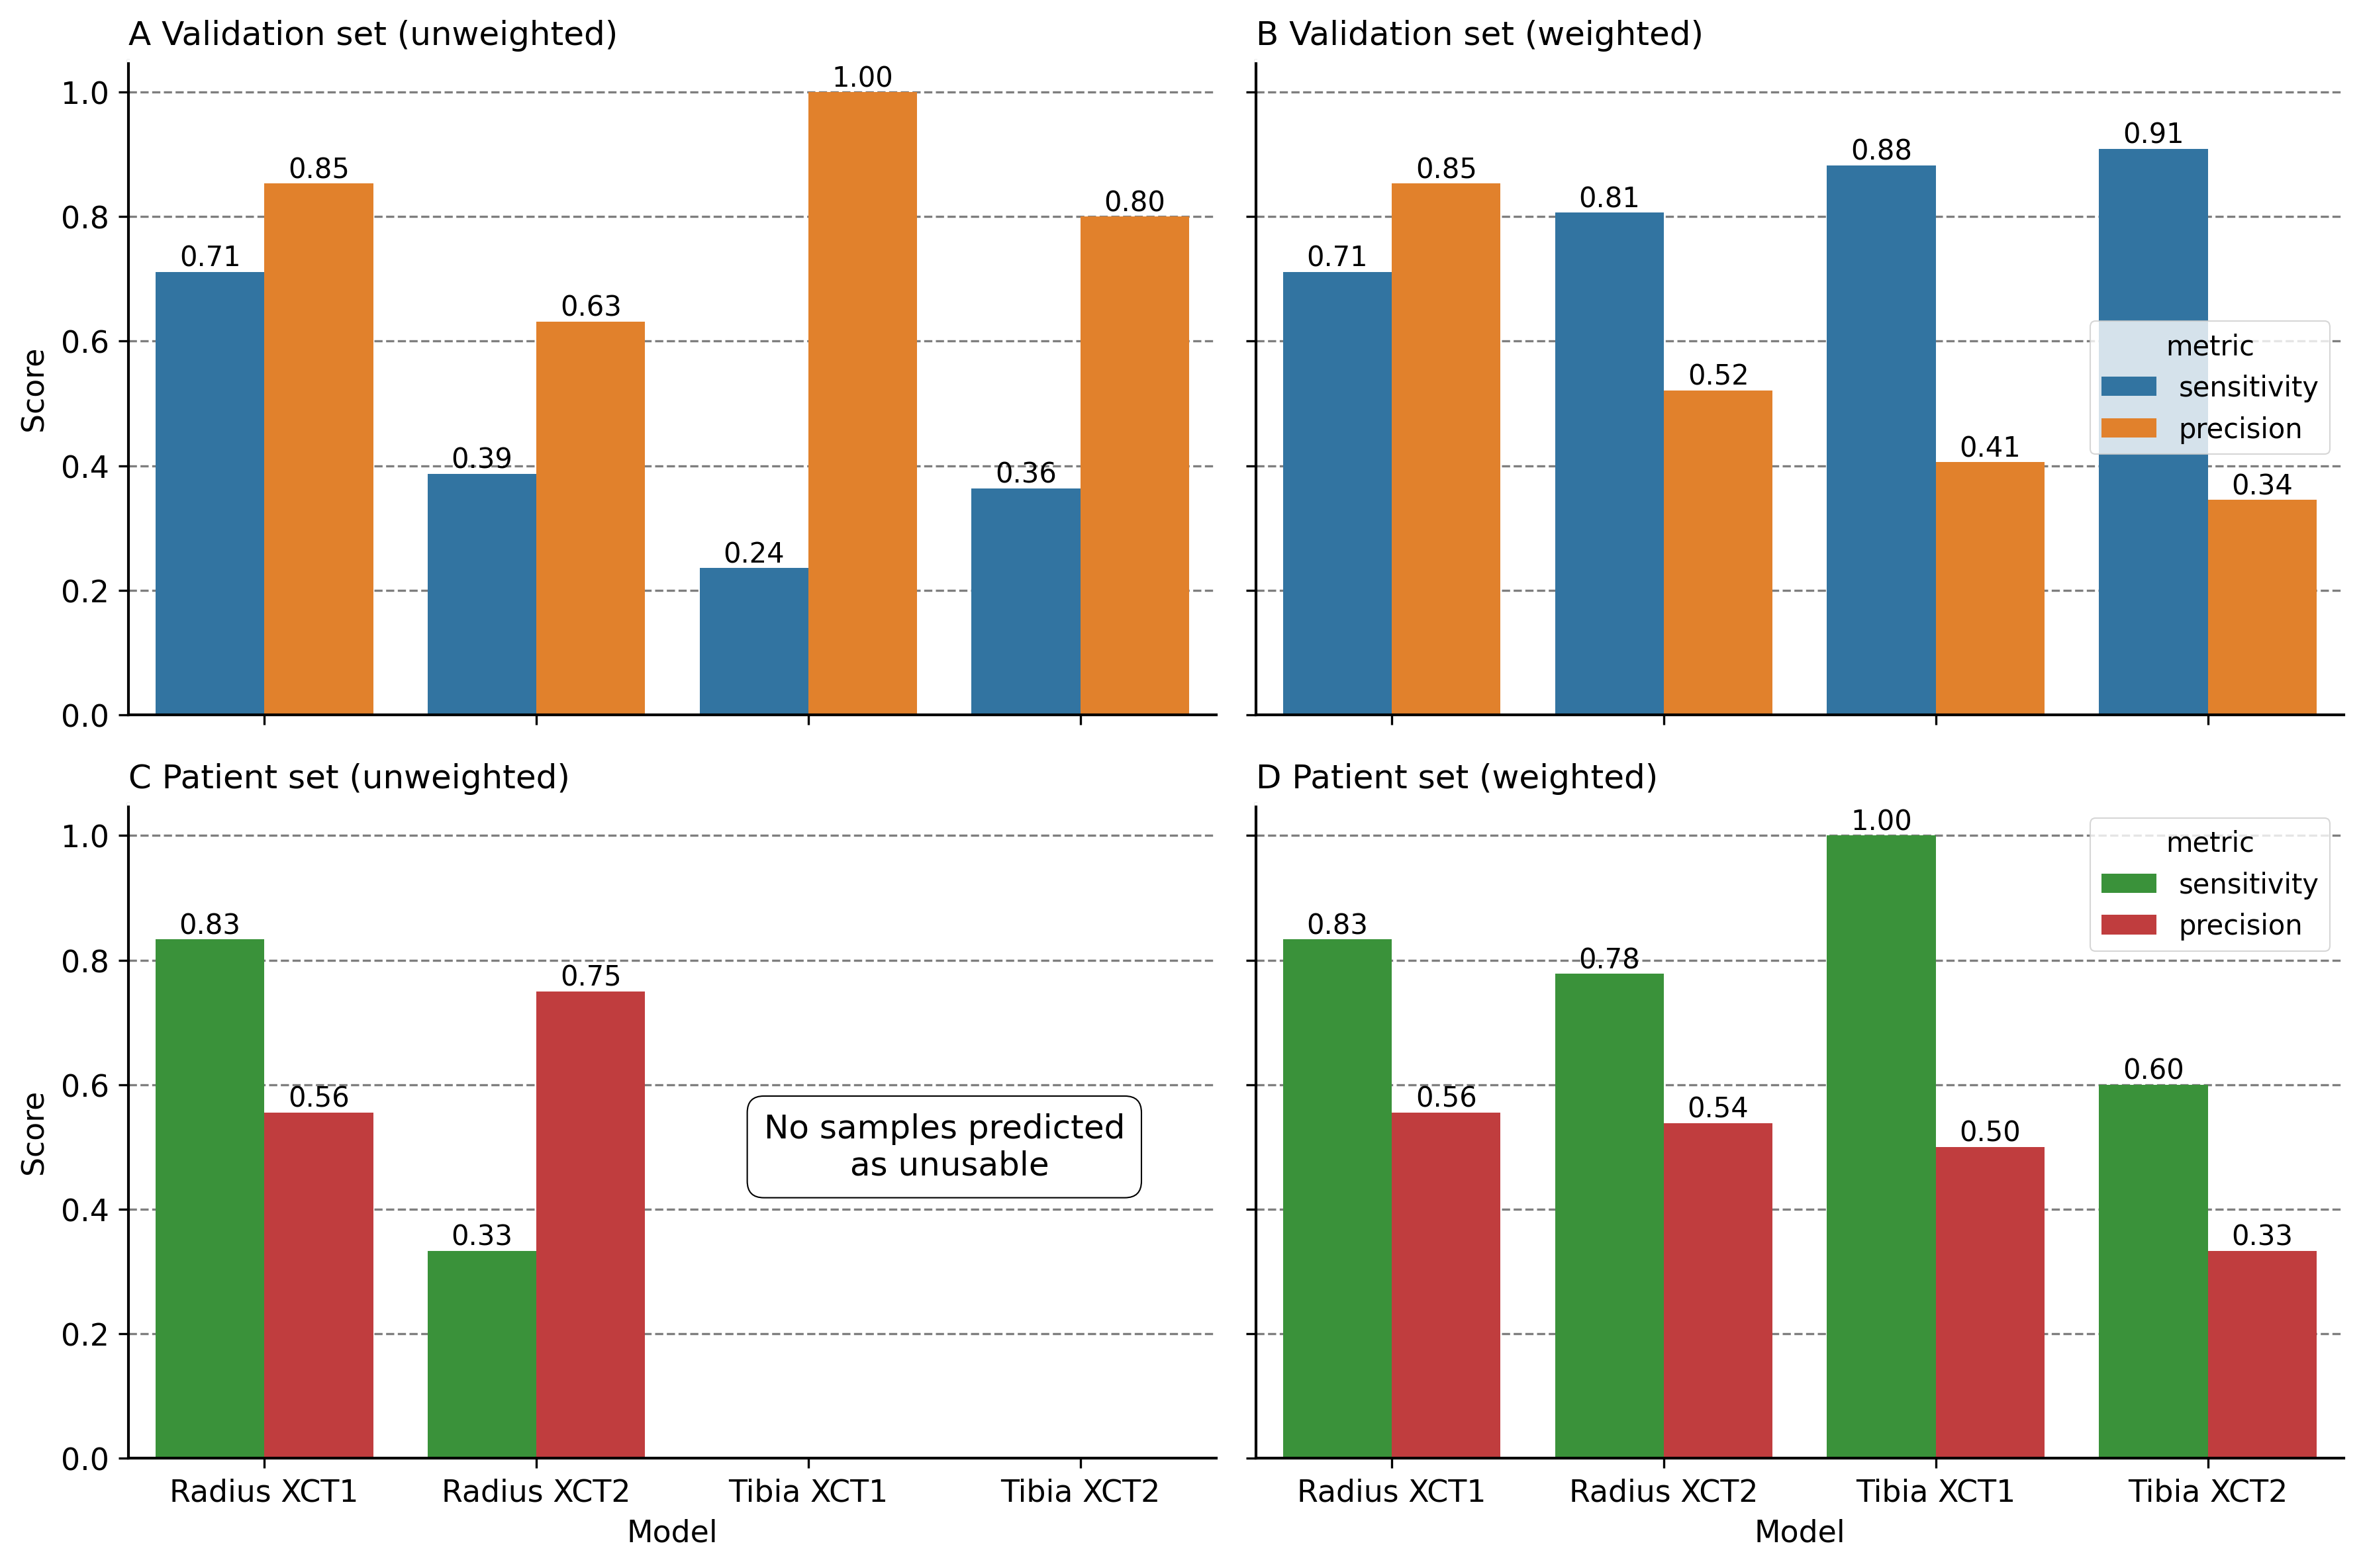

In [6]:
fig, ax = plt.subplots(figsize=(12, 8), dpi=300, ncols=2, nrows=2, sharex=True, sharey=True)
# set white background for the figure, bigger label size, and black axes

for i, (dataset, grp) in enumerate(result_scores.groupby(['dataset', 'balanced'])):
    letter_order = ['C', 'D', 'A', 'B']
    # melt df
    grp_melted = grp.melt(id_vars=[col for col in grp.columns if col not in ['sensitivity', 'precision']], 
                          value_vars=['sensitivity', 'precision'], 
                          var_name='metric', 
                          value_name='score')
    x_coord = 0 if dataset[0] == 'validation set' else 1
    y_coord = 0 if dataset[1] == 'unweighted' else 1

    is_d_or_b = letter_order[i] in ['D', 'B']  # only show legend for plots d and b
    color_palette = sns.color_palette("tab10", 4)
    colors = color_palette[:2] if dataset[0] == 'validation set' else color_palette[2:]
    sns.barplot(data=grp_melted, x='model', y='score', hue='metric', ax=ax[x_coord, y_coord], palette=colors, legend=is_d_or_b)
    for p in ax[x_coord, y_coord].patches:
        if p.get_height() <= 0:
            continue
        ax[x_coord, y_coord].annotate(f"{p.get_height():.2f}", (p.get_x() + p.get_width() / 2., p.get_height()), 
                                      ha='center', va='bottom', fontsize=10)
        
    # at plot C, add a box that says "No samples predicted as unusable"
    if letter_order[i] == 'C':
        ax[x_coord, y_coord].text(2.5, 0.5, "No samples predicted\n as unusable", 
                                  horizontalalignment='center', verticalalignment='center', 
                                  fontsize=12, bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.5'))
    ax[x_coord, y_coord].set_ylim(0, 1)
    # make title left aligned and add letter (A, B, C, D) to each subplot
    ax[x_coord, y_coord].set_title(f"{letter_order[i]} {dataset[0].capitalize()} ({dataset[1]})", loc='left', fontsize=12)
    ax[x_coord, y_coord].set_ylabel('Score')
    ax[x_coord, y_coord].set_xlabel('Model')
    ax[x_coord, y_coord].set_ylim(0, 1.05)
    style_ax(ax[x_coord, y_coord])
    ax[x_coord, y_coord].grid(True, linestyle='--', alpha=0.5, color='black', axis='y')
plt.tight_layout()
plt.savefig('figures/precision_recall_scores.pdf', bbox_inches='tight')
plt.show()

## Get prediction quality by grade

In [7]:
test_predictions = all_predictions[(all_predictions['original_set'] == 'test') & (all_predictions['samples'] == 'all')].copy()
# check how often the model is correct given a grade
def correct_preds_by_grade(df, grade, percent=False):
    df = df[df['grade'] == grade].copy()
    if percent:
        return df[df['correct'] == True].shape[0] / df.shape[0]
    return df[df['correct'] == True].shape[0]

def total_preds_by_grade(df, grade):
    df = df[df['grade'] == grade].copy()
    return df.shape[0]

for i in range(1, 6):
    print(f"Grade {i}: {correct_preds_by_grade(test_predictions, i, True)*100:.2f}% correct predictions "\
          f"({correct_preds_by_grade(test_predictions, i)} of {total_preds_by_grade(test_predictions, i)})")


Grade 1: 95.26% correct predictions (402 of 422)
Grade 2: 84.72% correct predictions (366 of 432)
Grade 3: 76.60% correct predictions (72 of 94)
Grade 4: 63.84% correct predictions (143 of 224)
Grade 5: 82.14% correct predictions (23 of 28)


In [8]:
test_predictions

,true,pred,probability,correct,original_set,grade,logits,model,no_pred,balanced,samples
0,pass,pass,0.918338,True,test,2.0,-2.419978,Tibia XCT1,0,False,all
2,fail,fail,0.845061,True,test,3.0,1.696375,Tibia XCT1,2,False,all
9,pass,pass,0.994611,True,test,1.0,-5.217933,Tibia XCT1,9,False,all
11,pass,pass,0.993876,True,test,1.0,-5.089421,Tibia XCT1,11,False,all
15,pass,pass,0.853708,True,test,2.0,-1.763988,Tibia XCT1,15,False,all
...,...,...,...,...,...,...,...,...,...,...,...
3990,pass,pass,0.986830,True,test,1.0,-4.316570,Radius XCT2,1990,True,all
3991,fail,fail,0.804576,True,test,5.0,1.415141,Radius XCT2,1991,True,all
3994,pass,pass,0.508223,True,test,1.0,-0.032895,Radius XCT2,1994,True,all
3995,pass,pass,0.885155,True,test,2.0,-2.042178,Radius XCT2,1995,True,all


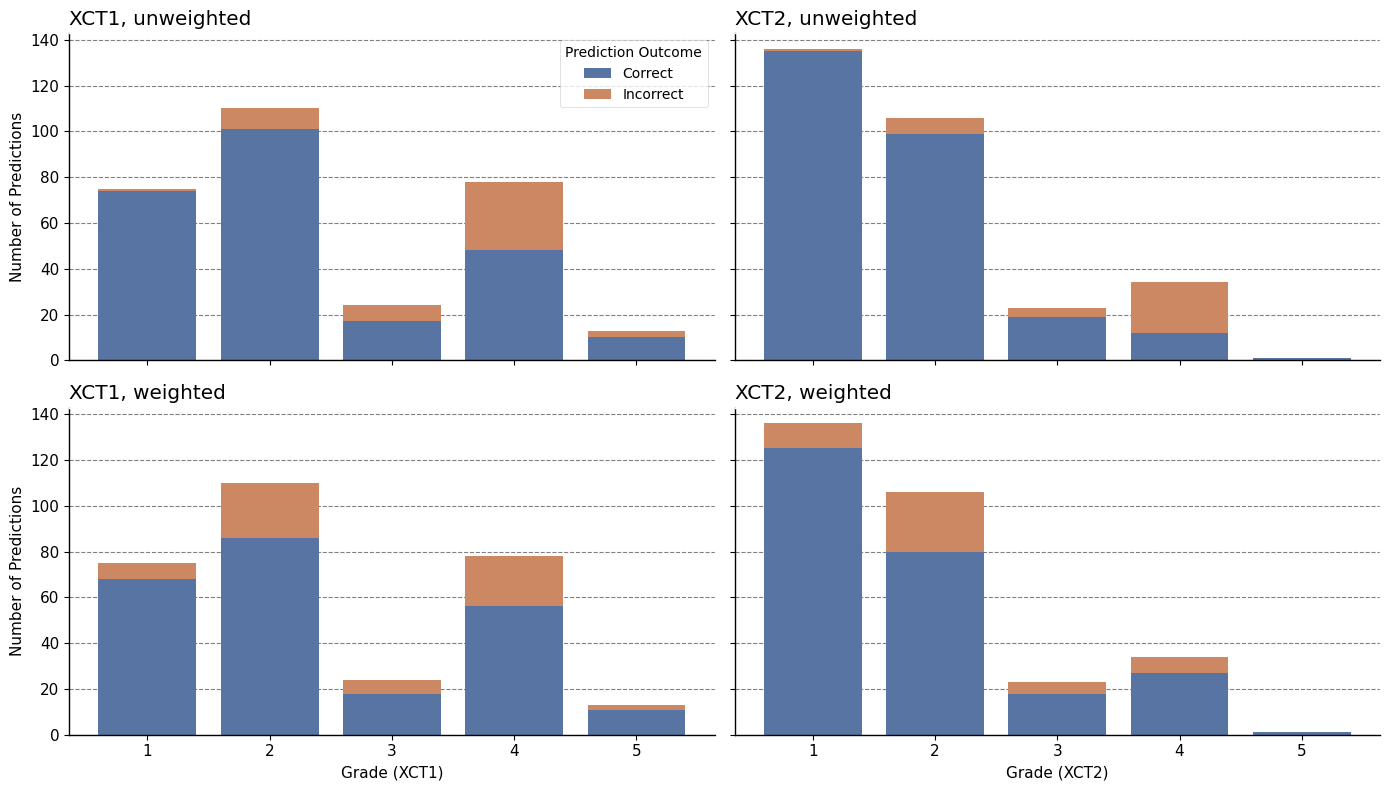

In [9]:
def get_correct_incorrect_counts(df):
    summary = df.groupby(['grade', 'correct']).size().reset_index(name='count')
    pivot_df = summary.pivot(index='grade', columns='correct', values='count').fillna(0)
    pivot_df.columns = ['Incorrect', 'Correct']  # False becomes 'Incorrect', True becomes 'Correct'
    pivot_df = pivot_df.reset_index()
    return pivot_df

def plot_stacked_bar(pivot_df, ax, xct_version=None, balanced=None, show_legend=None, col=None):
    grades = pivot_df['grade'].astype(int).astype(str)
    correct = pivot_df['Correct']
    incorrect = pivot_df['Incorrect']
    balance = 'weighted' if balanced else 'unweighted'

    ax.xaxis.grid(False)
    # y axis numbering in steps of 20
    ax.set_yticks(np.arange(0, max(correct.max(), incorrect.max()) + 30, 20))
    ax.bar(grades, correct, label='Correct', color='#5874A3')
    ax.bar(grades, incorrect, bottom=correct, label='Incorrect', color='#CB8862')

    if balanced:
        ax.set_xlabel(f'Grade ({xct_version})')
    
    if col == 0:
        ax.set_ylabel('Number of Predictions')
    ax.set_title(f'{xct_version}, {balance}', loc='left')
    if show_legend:
        ax.legend(title='Prediction Outcome')
    style_ax(ax)

fig, ax = plt.subplots(figsize=(14, 8), ncols=2, nrows=2, sharex=True, sharey=True)
for i in range(2):
    # split again by weighted/unweighted
    preds_by_balance = test_predictions[test_predictions['balanced'] == i] # 0 = False, 1 = True
    xct1_df = get_correct_incorrect_counts(preds_by_balance[preds_by_balance['model'].str.contains('XCT1')])
    plot_stacked_bar(xct1_df, ax=ax[i, 0], xct_version='XCT1', balanced=i, show_legend=i == 0, col=0)
    xct2_df = get_correct_incorrect_counts(preds_by_balance[preds_by_balance['model'].str.contains('XCT2')])
    plot_stacked_bar(xct2_df, ax=ax[i, 1], xct_version='XCT2', balanced=i, col=1)
plt.tight_layout()
plt.show()

## Get the importance of features across bones

In [10]:
bone = ['radius', 'tibia']
xct = ['XCT1', 'XCT2']
weight= ['_balanced', '']

full_df = pd.DataFrame(columns=['feature', 'coefficient', 'bone', 'xct', 'model'])

for w in weight:
    for b in bone:
        for x in xct:
            df = pd.read_csv(f'data/coefficients_{x}_{b}{w}.csv')
            df = df.rename(columns={'Importance': 'coefficient', 'Feature': 'feature'})
            df['bone'] = b
            df['xct'] = x
            df['model'] = "balanced" if w == '_balanced' else "normal"

            full_df = pd.concat([full_df, df], ignore_index=True)

# remove .1 from feature name if it exists at the end
full_df['feature'] = full_df['feature'].str.replace(r'\.1$', '', regex=True)

full_df


/tmp/ipykernel_774595/1119860172.py:16: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  full_df = pd.concat([full_df, df], ignore_index=True)


,feature,coefficient,bone,xct,model
0,Tt.BMD,0.000000,radius,XCT1,balanced
1,Tt.Ar,0.000000,radius,XCT1,balanced
2,Tb.BMD,-1.246039,radius,XCT1,balanced
3,BV/TV,-1.369055,radius,XCT1,balanced
4,Tb.N,3.213962,radius,XCT1,balanced
...,...,...,...,...,...
107,Ct.Th,0.795459,tibia,XCT2,normal
108,Ct.Po,-0.586367,tibia,XCT2,normal
109,Ct.Po.Dm,-1.307007,tibia,XCT2,normal
110,Ct.Pm,0.000000,tibia,XCT2,normal


In [11]:
# group features by model and mean out the coefficient (ignore bone and xct)
grouped_df = full_df.groupby(['feature', 'model']).agg({'coefficient': 'mean'}).reset_index()
grouped_df = grouped_df.sort_values(by=['model', 'coefficient'], ascending=[True, False])
grouped_df['model'] = grouped_df['model'].replace({'balanced': 'weighted', 'normal': 'unweighted'})
grouped_df.reset_index(drop=True, inplace=True)
grouped_df = grouped_df.drop_duplicates(subset=['feature', 'model'])
grouped_df['bone'] = 'combined'
grouped_df['xct'] = 'combined'
# combine grouped_df with full_df 
#full_df = pd.concat([grouped_df, full_df], ignore_index=True)
#full_df = full_df[['feature', 'importance', 'bone', 'xct', 'model']]
#full_df

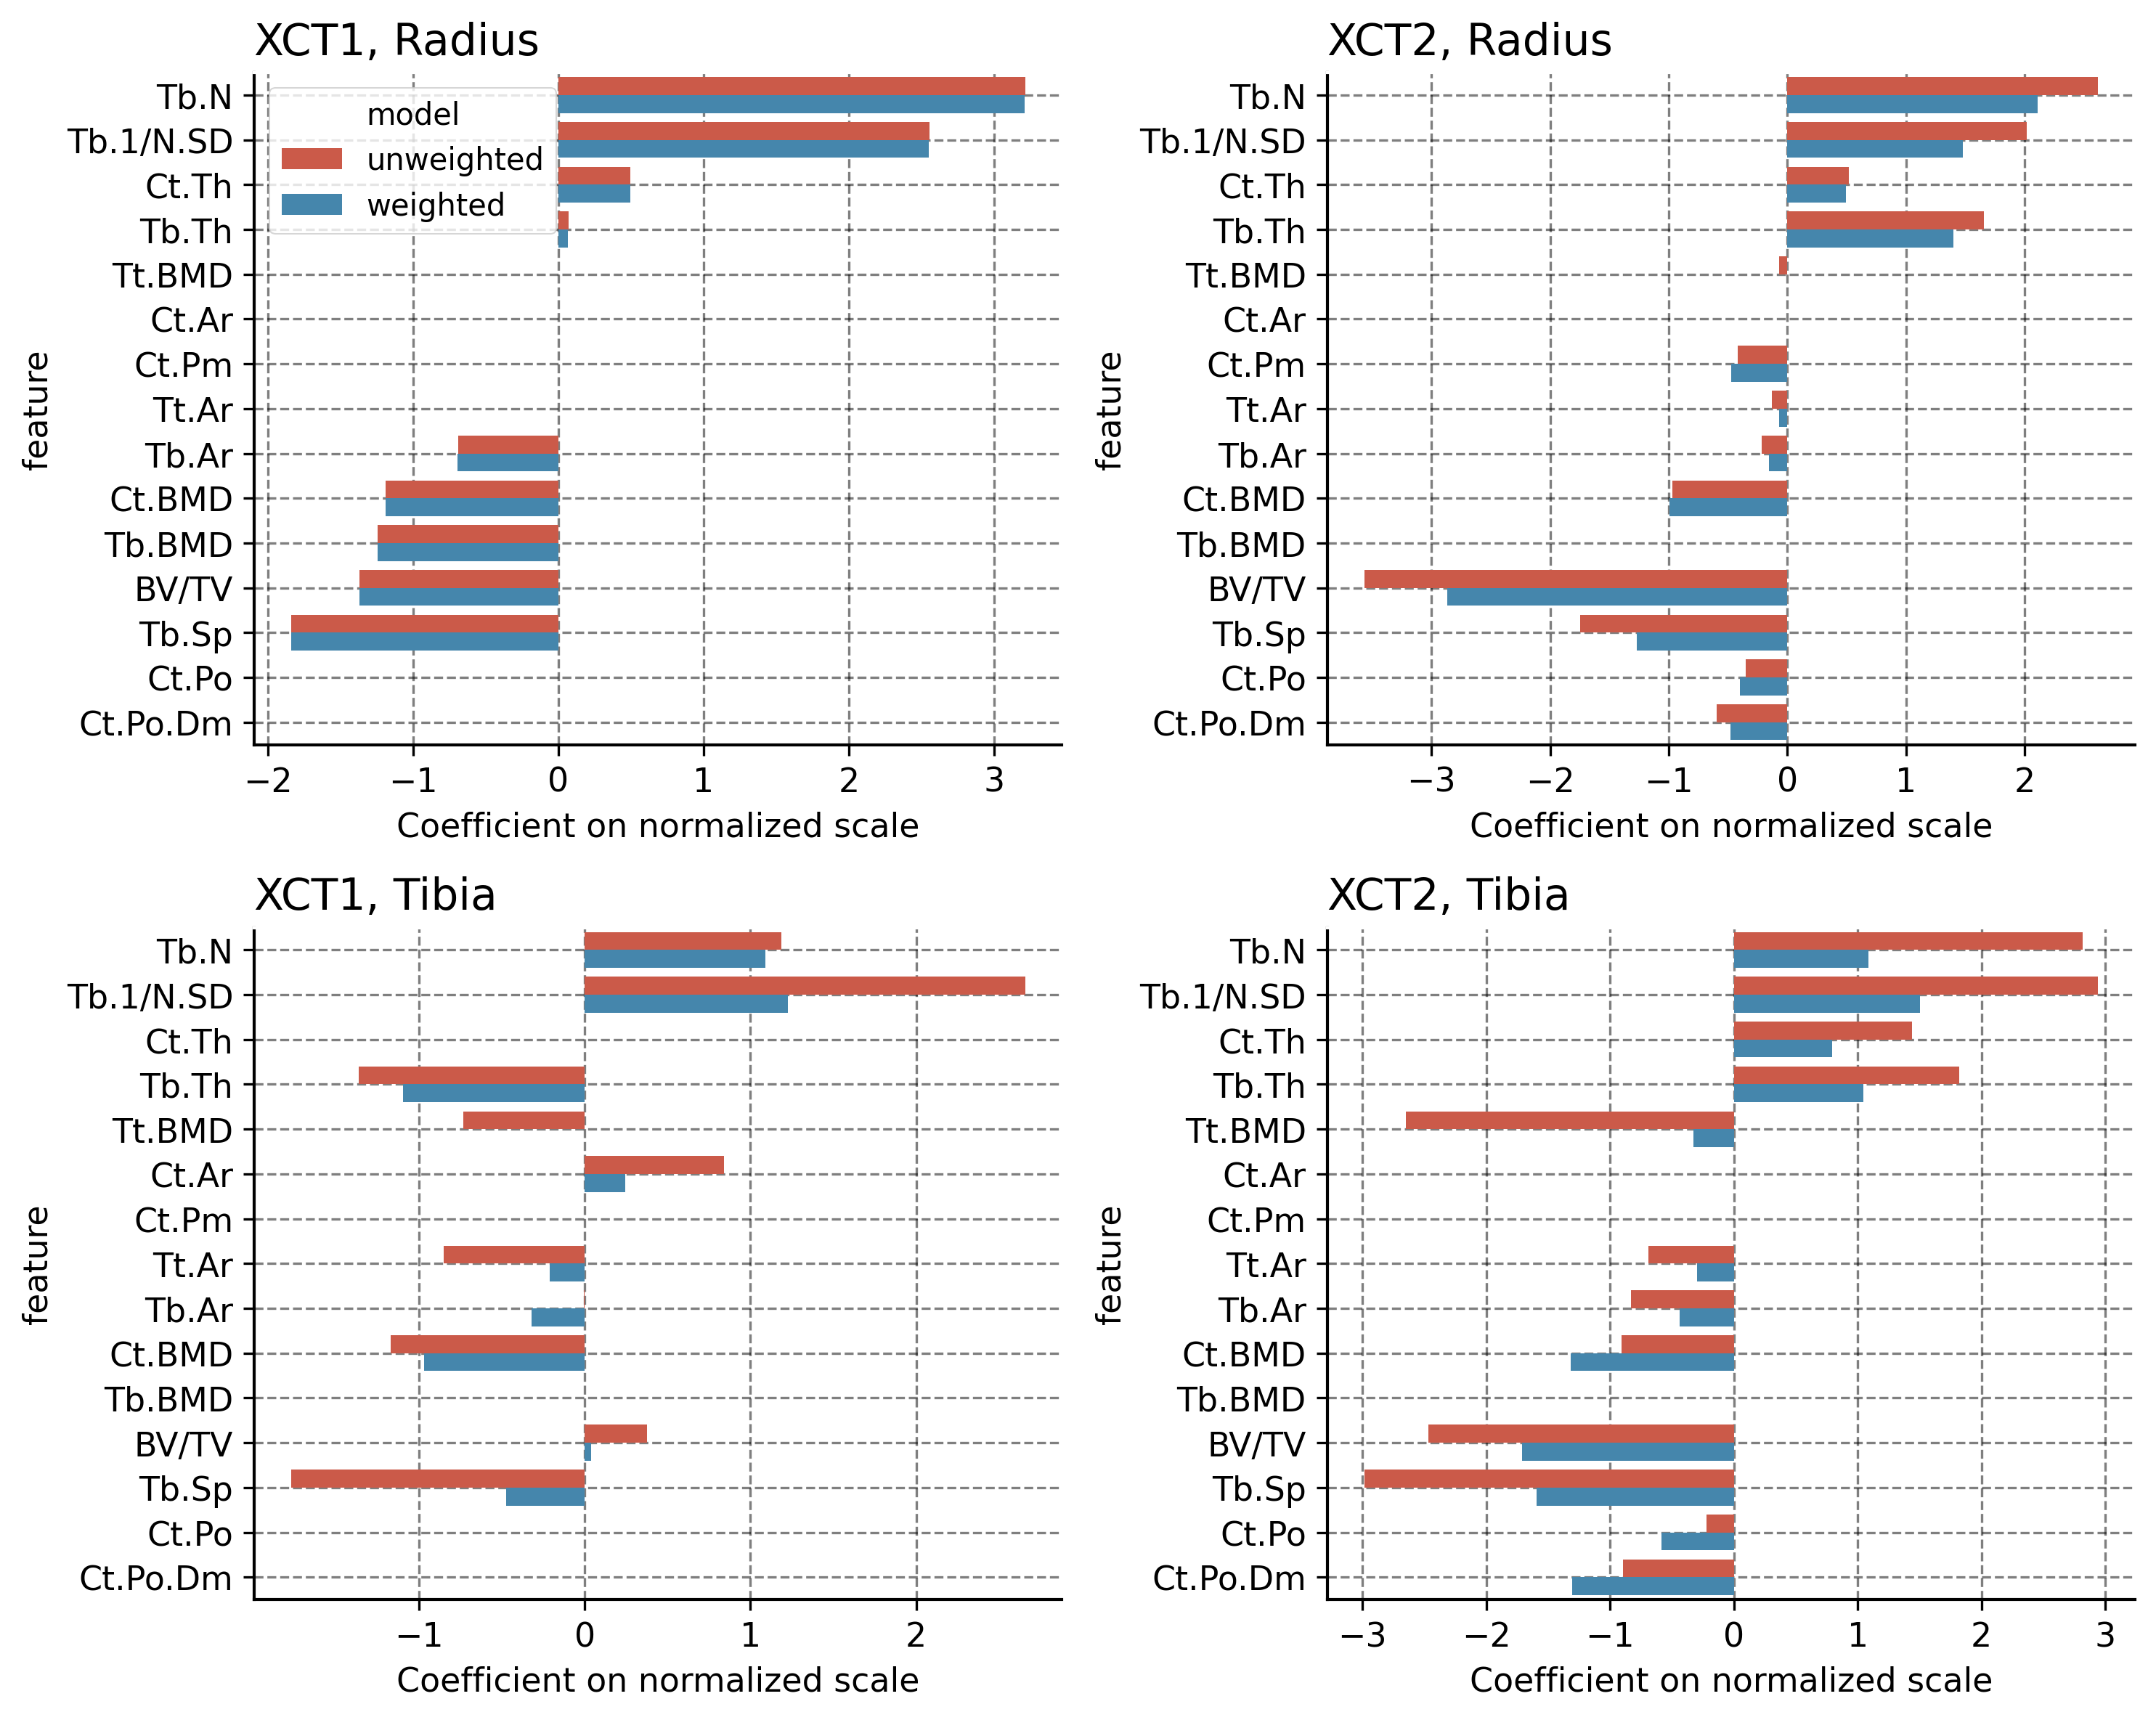

In [12]:
full_df['model'] = full_df['model'].replace({'balanced': 'weighted', 'normal': 'unweighted'})
unique_combinations = full_df[['bone', 'xct']].drop_duplicates()
# sort unique combinations
unique_combinations = unique_combinations.sort_values(by=['bone', 'xct'])
full_df = full_df.sort_values(by=['coefficient'], ascending=False)
param_order = full_df['feature'].unique()
param_order = ['Tb.N', 'Tb.1/N.SD', 'Ct.Th', 'Tb.Th', 'Tt.BMD', 'Ct.Ar', 'Ct.Pm', 'Tt.Ar', 'Tb.Ar', 'Ct.BMD', 'Tb.BMD', 'BV/TV', 'Tb.Sp', 'Ct.Po', 'Ct.Po.Dm']
n_cols = 2 
n_rows = (len(unique_combinations) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows), squeeze=False, dpi=300)

for idx, (c_val, d_val) in enumerate(unique_combinations.values):
    ax = axes[idx // n_cols][idx % n_cols]
    
    subset = full_df[(full_df['bone'] == c_val) & (full_df['xct'] == d_val)]
    
    sns.barplot(data=subset, x='coefficient', y='feature', hue='model', ax=ax, palette=['#E14A33', '#348ABD'], order=param_order)
    
    ax.set_title(f'{d_val}, {c_val.capitalize()}', loc='left')
    ax.set_xlabel('Coefficient on normalized scale')
    style_ax(ax)
    
    if idx != 0:
        ax.get_legend().remove()

for i in range(len(unique_combinations), n_rows * n_cols):
    fig.delaxes(axes[i // n_cols][i % n_cols])

plt.tight_layout()
plt.savefig('figures/feature_importances.pdf', bbox_inches='tight')
plt.show()

In [ ]:
# plot both model feature importances side by side in a single plot
fig, ax = plt.subplots(figsize=(8, 5), dpi=300)
sns.barplot(data=grouped_df, x='importance', y='feature', hue='model', ax=ax, palette=['#E14A33', '#348ABD'])
ax.set_xlabel('Average coefficient (on normalized scale)')
ax.set_ylabel('Feature')
style_ax(ax)
plt.tight_layout()
plt.savefig(f'figures/coefficients.pdf', bbox_inches='tight')
plt.show()

## Get for all predictions their overlap

In [ ]:
all_predictions_test = all_predictions[all_predictions['original_set'] == 'test'][['no_pred', 'pred', 'balanced']].copy()
all_predictions_test

,no_pred,pred,balanced
0,0,pass,False
2,2,fail,False
9,9,pass,False
11,11,pass,False
15,15,pass,False
...,...,...,...
4235,115,fail,True
4236,116,fail,True
4237,117,pass,True
4238,118,pass,True


In [ ]:
all_predictions_test_wide = all_predictions_test.pivot(index='no_pred', columns='balanced', values='pred')
all_predictions_test_wide.columns = [f'out_{col}' for col in all_predictions_test_wide.columns]
ap_tw = all_predictions_test_wide.reset_index() # ap_tw = all_predictions_test_wide
ap_tw

ValueError: Index contains duplicate entries, cannot reshape

In [ ]:
subset_1 = len(set(ap_tw[(ap_tw['out_False'] == 'fail') & (ap_tw['out_True'] == 'pass')]['no_pred']))
subset_2 = len(set(ap_tw[(ap_tw['out_False'] == 'fail') & (ap_tw['out_True'] == 'fail')]['no_pred']))
subset_3 = len(set(ap_tw[(ap_tw['out_False'] == 'pass') & (ap_tw['out_True'] == 'fail')]['no_pred']))

print(f"unbalanced fail, balanced pass: {subset_1}")
print(f"unbalanced fail, balanced fail: {subset_2}")
print(f"unbalanced pass, balanced fail: {subset_3}")

unbalanced fail, balanced pass: 0
unbalanced fail, balanced fail: 103
unbalanced pass, balanced fail: 86


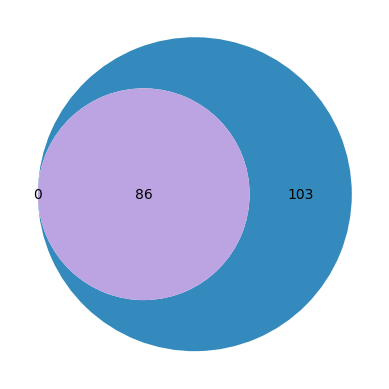

In [ ]:
venn2(subsets = [subset_1, subset_2, subset_3], set_labels = ('', '', ''), set_colors=("#D76084", '#348ABD'), alpha=1)
plt.savefig(f'figures/venn_diagram_overlap.pdf', bbox_inches='tight', dpi=300)
plt.show()

# Showing dataset distribution per combination

In [14]:
all_predictions
# group by model and find the number of pass/fail in the true column and then plot that per model
model_counts = (
    all_predictions
    .drop(all_predictions[all_predictions['balanced'] == True].index)
    .groupby(['samples', 'model', 'true'])
    .size()
    .unstack(fill_value=0)
    .reset_index()
    .rename(columns={'pass': 'usable', 'fail': 'unusable'})
    .melt(id_vars=['samples', 'model'], var_name='Outcome', value_name='Count')
)
model_counts

,samples,model,Outcome,Count
0,all,Radius XCT1,unusable,267
1,all,Radius XCT2,unusable,100
2,all,Tibia XCT1,unusable,56
3,all,Tibia XCT2,unusable,38
4,patients,Radius XCT1,unusable,6
5,patients,Radius XCT2,unusable,9
6,patients,Tibia XCT1,unusable,2
7,patients,Tibia XCT2,unusable,5
8,all,Radius XCT1,usable,233
9,all,Radius XCT2,usable,400


In [15]:
model_counts_test = pd.DataFrame({'model': ['Radius XCT1', 'Radius XCT2', 'Tibia XCT1', 'Tibia XCT2', 
                                            'Radius XCT1', 'Radius XCT2', 'Tibia XCT1', 'Tibia XCT2'],
                                  'Outcome': ['unusable', 'unusable', 'unusable', 'unusable',
                                              'usable', 'usable', 'usable', 'usable'],
                                  'Count': [6, 9, 2, 5, 12, 33, 16, 37]})
model_counts_test

,model,Outcome,Count
0,Radius XCT1,unusable,6
1,Radius XCT2,unusable,9
2,Tibia XCT1,unusable,2
3,Tibia XCT2,unusable,5
4,Radius XCT1,usable,12
5,Radius XCT2,usable,33
6,Tibia XCT1,usable,16
7,Tibia XCT2,usable,37


In [16]:
model_counts

,samples,model,Outcome,Count
0,all,Radius XCT1,unusable,267
1,all,Radius XCT2,unusable,100
2,all,Tibia XCT1,unusable,56
3,all,Tibia XCT2,unusable,38
4,patients,Radius XCT1,unusable,6
5,patients,Radius XCT2,unusable,9
6,patients,Tibia XCT1,unusable,2
7,patients,Tibia XCT2,unusable,5
8,all,Radius XCT1,usable,233
9,all,Radius XCT2,usable,400


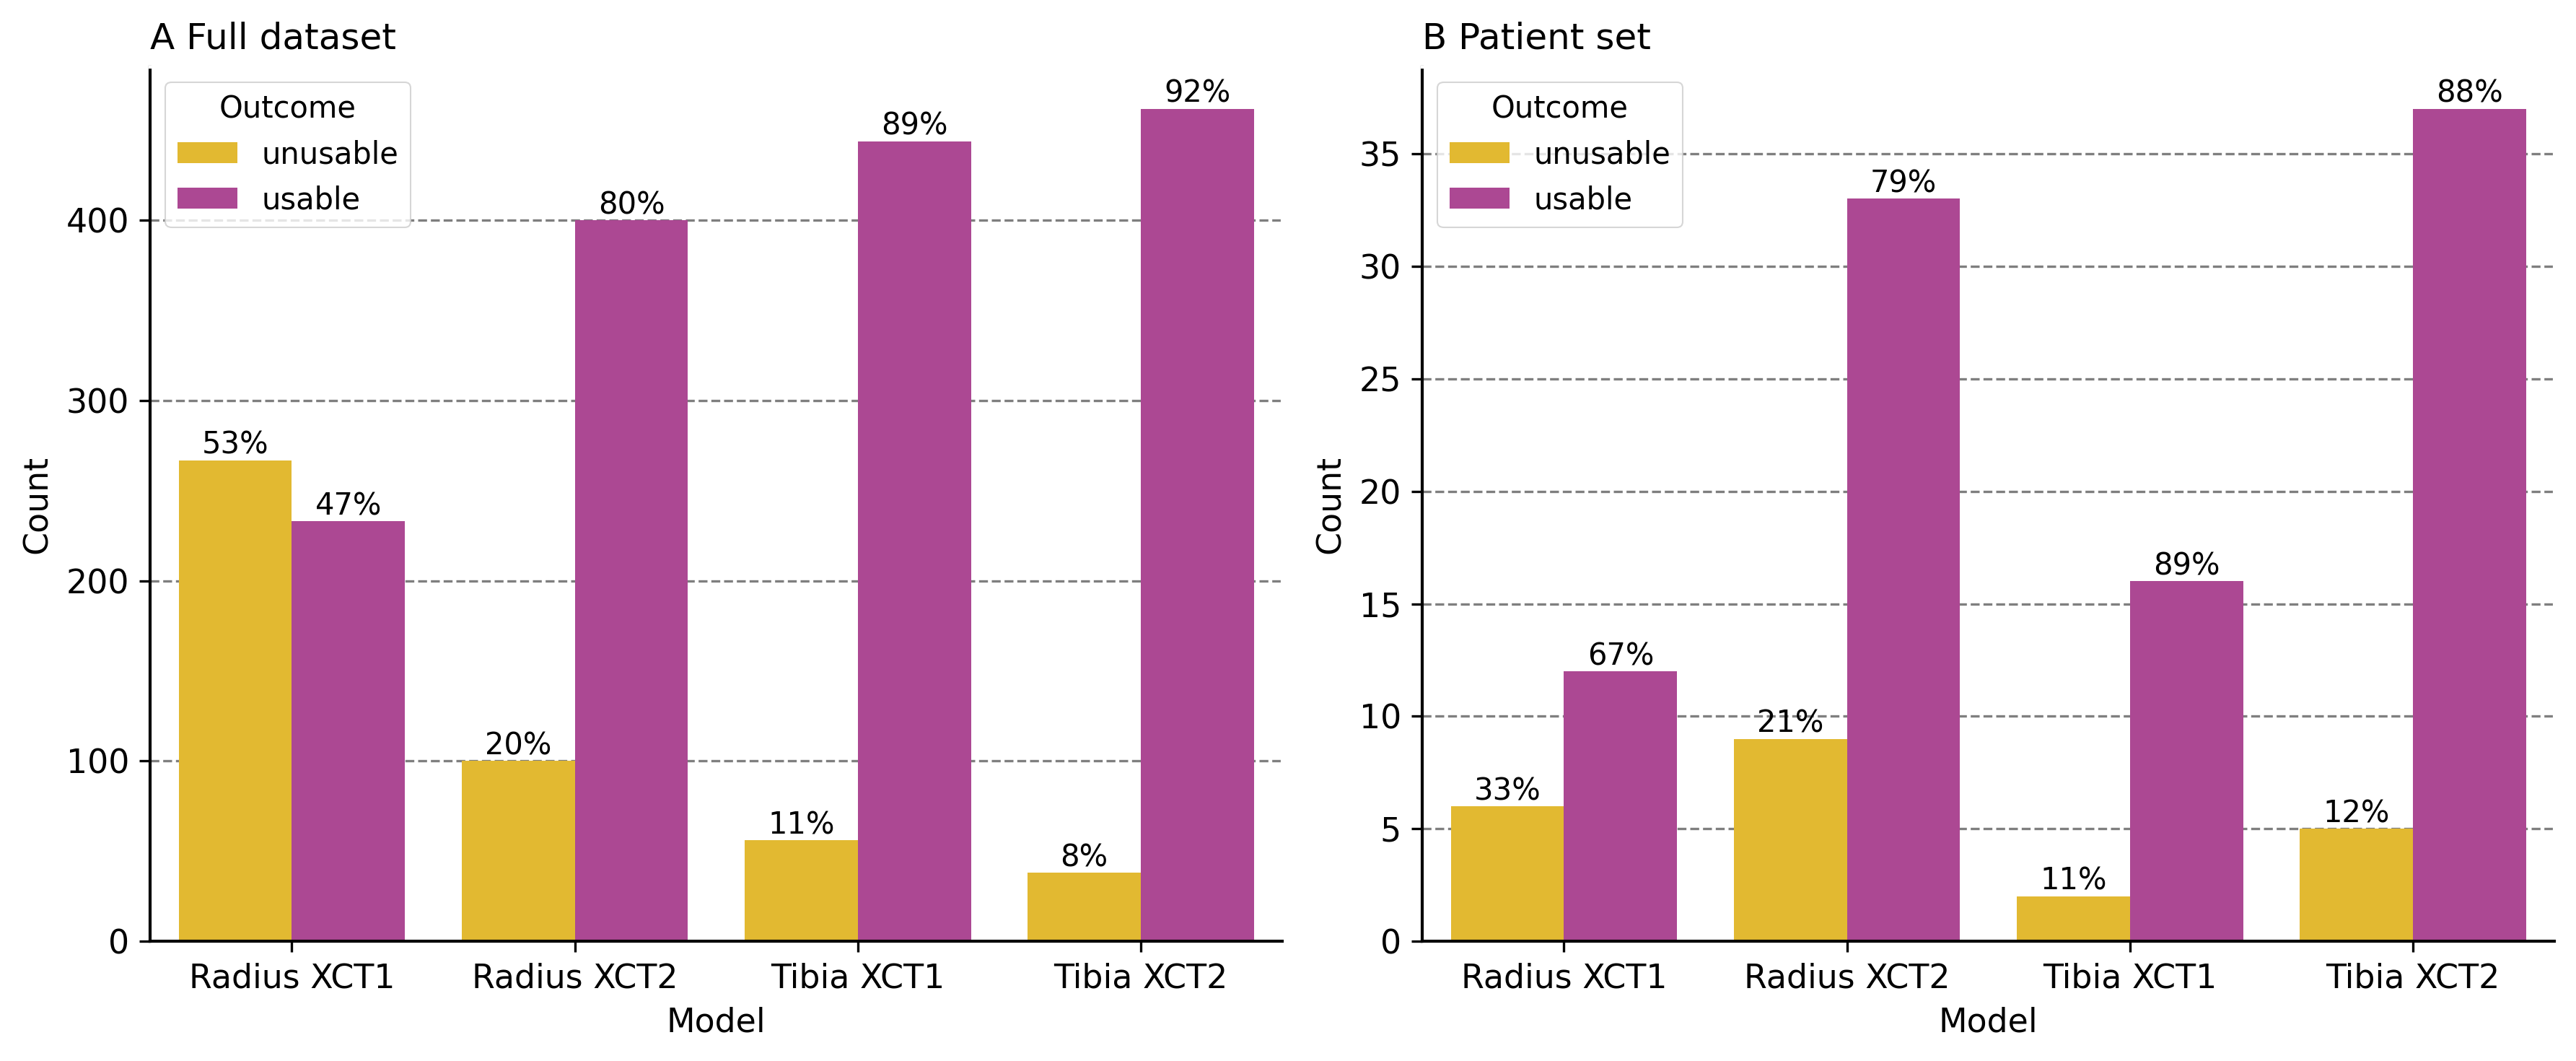

In [17]:
# normalize the counts to percentages
#model_counts['Count'] = model_counts['Count'] / model_counts.groupby('model')['Count'].transform('sum') * 100
fig, ax = plt.subplots(figsize=(12, 5), dpi=300, ncols=2, nrows=1)
for i, (samples, grp) in enumerate(model_counts.groupby('samples')):
    letter_order = ['A', 'B']
    sns.barplot(data=grp, x='model', y='Count', hue='Outcome', ax=ax[i], palette=['#FFC914', '#BD379B'])
    # total samples per xct
    total_samples = [grp[grp['model'].str.contains('XCT1')]['Count'].sum() / 2,
                      grp[grp['model'].str.contains('XCT2')]['Count'].sum()/ 2] * 4

    for j, p in enumerate(ax[i].patches):
        if p.get_height() <= 0:
            continue
        ax[i].annotate(f"{(p.get_height() / total_samples[j])*100:.0f}%", (p.get_x() + p.get_width() / 2., p.get_height()), 
                       ha='center', va='bottom', fontsize=10)
    ax[i].set_title(f"{letter_order[i]} {'Full dataset' if samples == 'all' else 'Patient set'}", loc='left', fontsize=12)
    ax[i].set_xlabel('Model')
    ax[i].set_ylabel('Count')
    style_ax(ax[i])
    #plt.title('Count of Usable and Unusable Predictions per Model')
plt.tight_layout()
plt.savefig(f'figures/dataset_distribution.pdf', bbox_inches='tight')
plt.show()

## Show confidence scores

In [ ]:
filtered_predictions = all_predictions[(all_predictions['original_set'] == 'test') & (all_predictions['samples'] == 'all')].copy()
filtered_predictions

,true,pred,probability,correct,original_set,grade,logits,model,no_pred,balanced,samples
0,pass,pass,0.918338,True,test,2.0,-2.419978,Tibia XCT1,0,False,all
2,fail,fail,0.845061,True,test,3.0,1.696375,Tibia XCT1,2,False,all
9,pass,pass,0.994611,True,test,1.0,-5.217933,Tibia XCT1,9,False,all
11,pass,pass,0.993876,True,test,1.0,-5.089421,Tibia XCT1,11,False,all
15,pass,pass,0.853708,True,test,2.0,-1.763988,Tibia XCT1,15,False,all
...,...,...,...,...,...,...,...,...,...,...,...
3990,pass,pass,0.986830,True,test,1.0,-4.316570,Radius XCT2,1990,True,all
3991,fail,fail,0.804576,True,test,5.0,1.415141,Radius XCT2,1991,True,all
3994,pass,pass,0.508223,True,test,1.0,-0.032895,Radius XCT2,1994,True,all
3995,pass,pass,0.885155,True,test,2.0,-2.042178,Radius XCT2,1995,True,all


In [ ]:
alpha = 0.1
all_thresholds = []
for param, group in filtered_predictions.groupby(['model', 'balanced']):
    si_scores = []
    # Loop through all calibration instances
    for i, true_class in enumerate(group['true']):
        # Get predicted probability for observed/true class
        predicted_prob = group['probability'].iloc[i]
        # do 1 - predicted_prob if true != pred
        if true_class != group['pred'].iloc[i]:
            predicted_prob = 1 - predicted_prob
        si_scores.append(1 - predicted_prob)
    si_scores = np.array(si_scores)

    number_of_samples = len(group)
    qlevel = (1- alpha) * ((number_of_samples + 1) / number_of_samples)
    threshold = np.percentile(si_scores, qlevel * 100)
    all_thresholds.append(threshold)
    print(f"Model: {param[0]}, Balanced: {param[1]}, Threshold: {threshold:.2f}, Samples: {number_of_samples}")
print(f"Highest threshold: {max(all_thresholds)}")

Model: Radius XCT1, Balanced: False, Threshold: 0.67, Samples: 150
Model: Radius XCT1, Balanced: True, Threshold: 0.68, Samples: 150
Model: Radius XCT2, Balanced: False, Threshold: 0.61, Samples: 150
Model: Radius XCT2, Balanced: True, Threshold: 0.74, Samples: 150
Model: Tibia XCT1, Balanced: False, Threshold: 0.47, Samples: 150
Model: Tibia XCT1, Balanced: True, Threshold: 0.61, Samples: 150
Model: Tibia XCT2, Balanced: False, Threshold: 0.27, Samples: 150
Model: Tibia XCT2, Balanced: True, Threshold: 0.63, Samples: 150
Highest threshold: 0.7367760685294767


In [ ]:
total_len = len(filtered_predictions)
removed_85 = total_len - len(filtered_predictions[filtered_predictions['probability'] >= 0.61]) 
print(f"Removed: {removed_85}/{total_len} ({removed_85 / total_len * 100:.0f}%)")
removed_95 = total_len - len(filtered_predictions[filtered_predictions['probability'] >= 0.80])
print(f"Removed: {removed_95}/{total_len} ({removed_95 / total_len * 100:.0f}%)")
info_85 = f"Distrust:\n{removed_85}/{total_len} ({removed_85 / total_len * 100:.0f}%)"
info_95 = f"Distrust:\n{removed_95}/{total_len} ({removed_95 / total_len * 100:.0f}%)"

Removed: 168/1200 (14%)
Removed: 459/1200 (38%)


/tmp/ipykernel_162522/1349355142.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(data=filtered_predictions, x='probability', bins=20, ax=ax, palette=['#348ABD'])


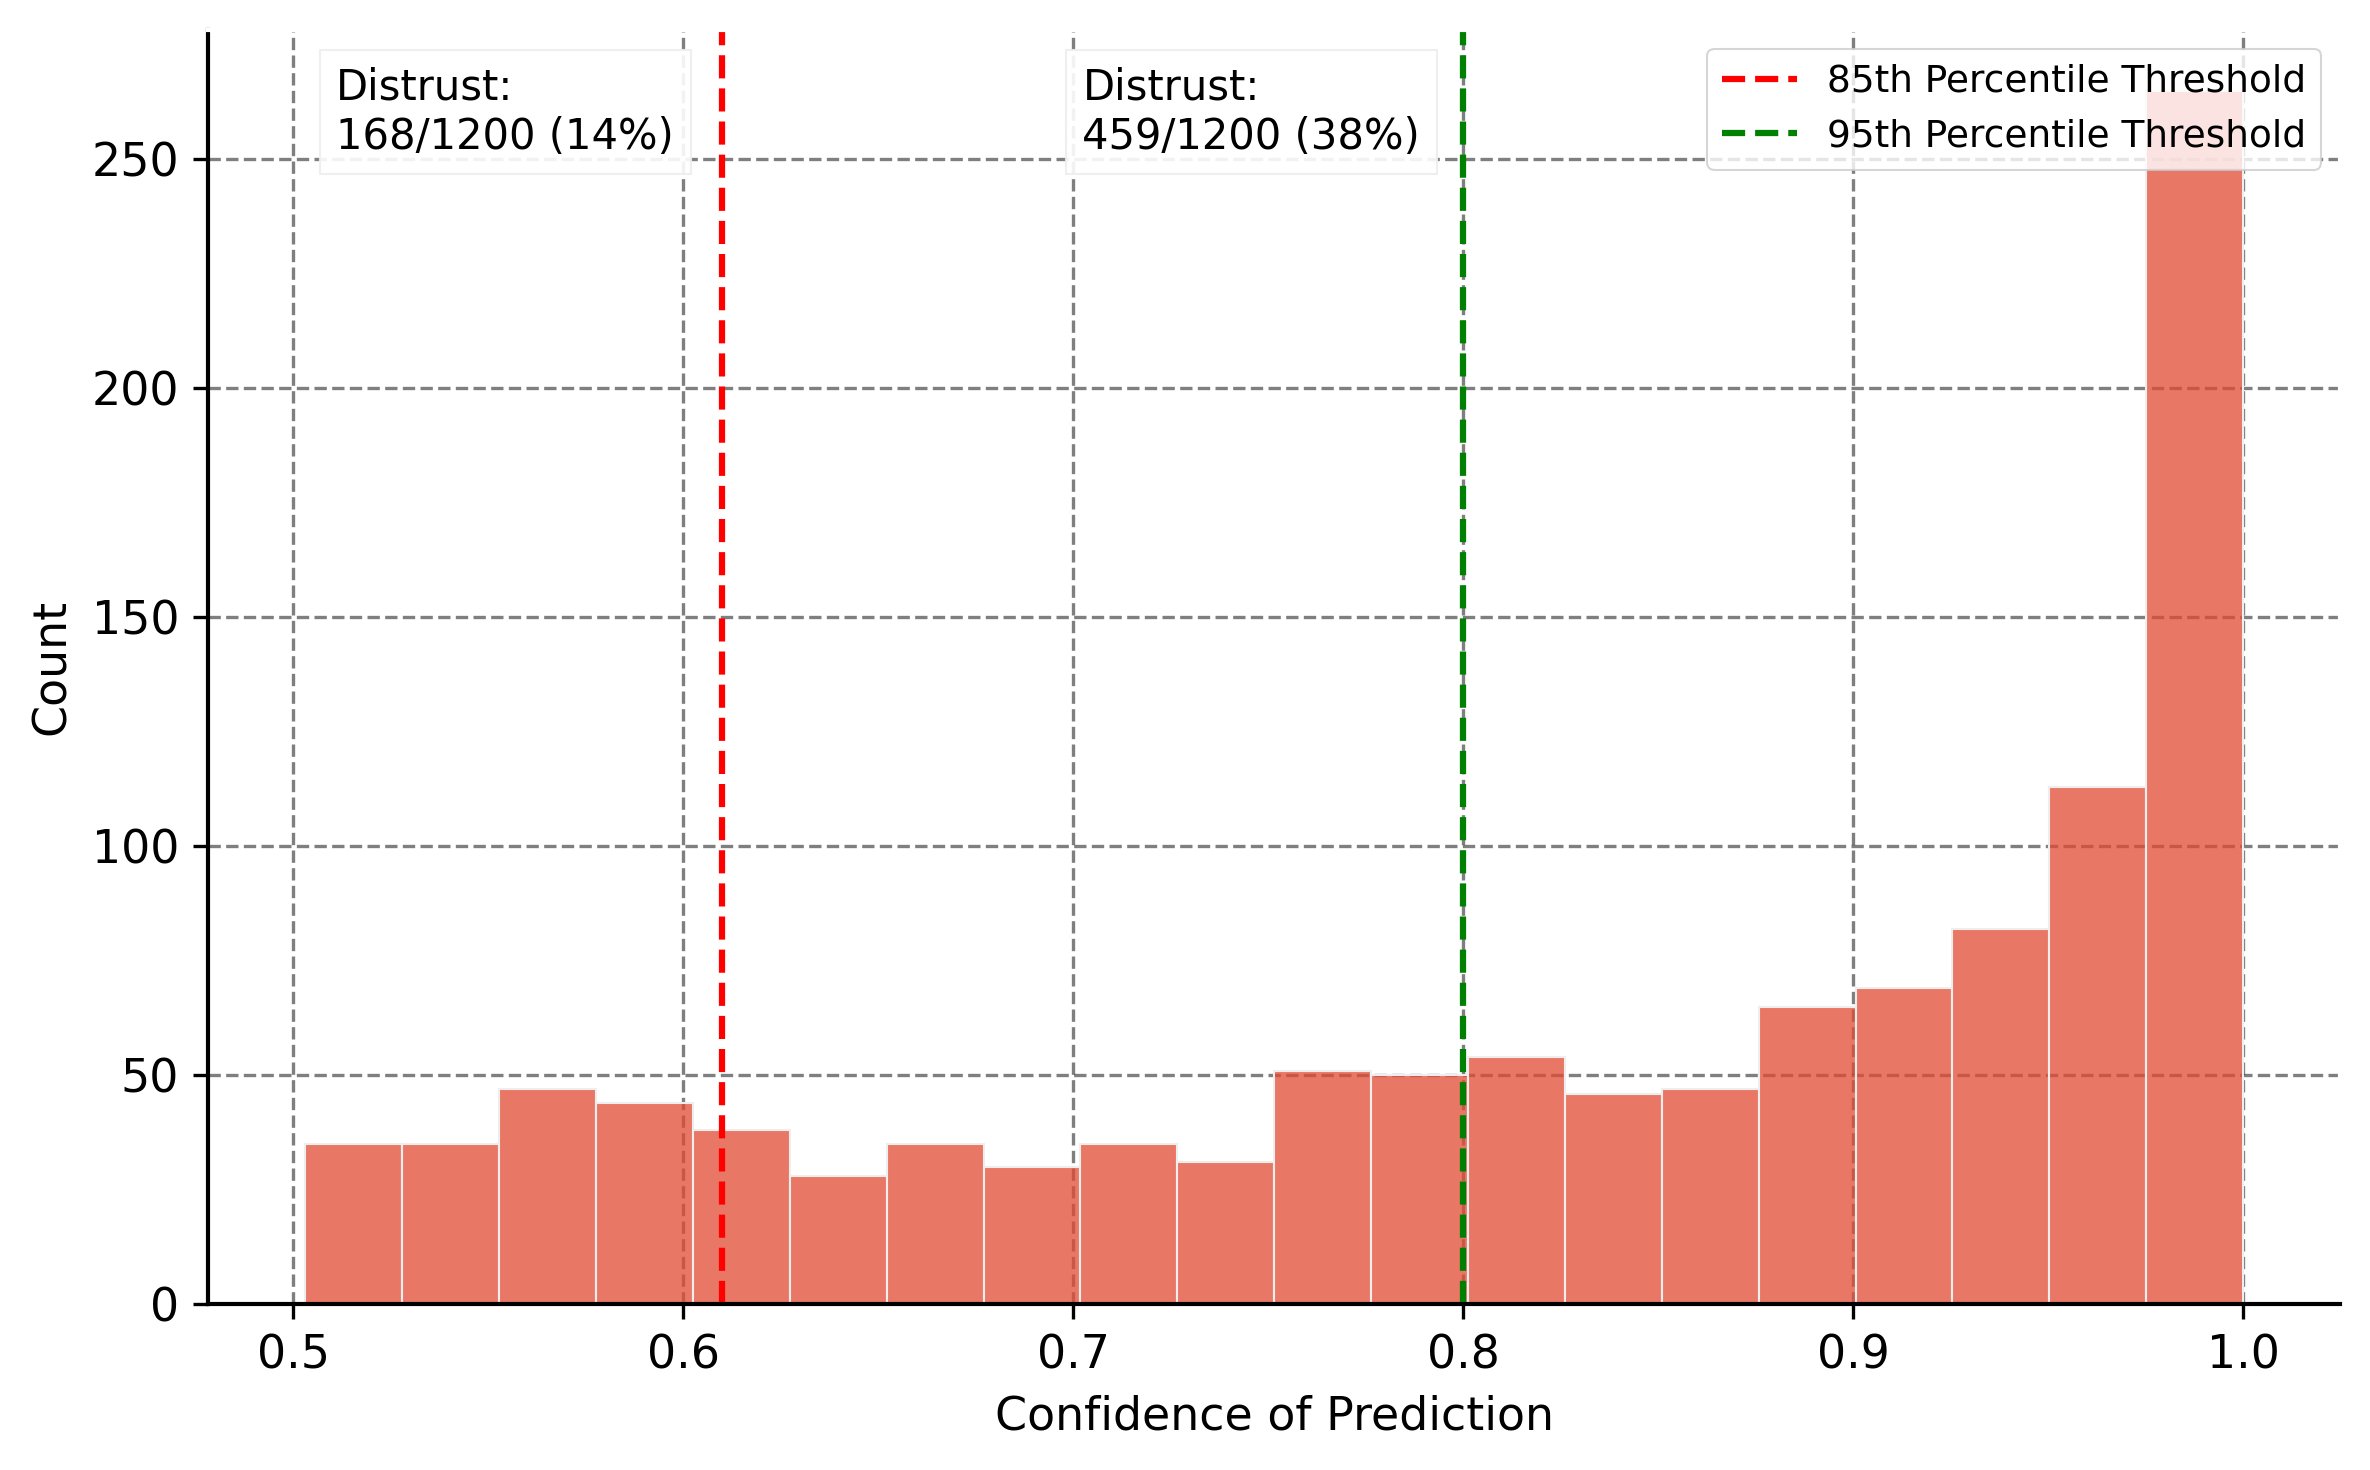

In [ ]:
# plot the distribution of the probability of the prediction
fig, ax = plt.subplots(figsize=(8, 5), dpi=300)
sns.histplot(data=filtered_predictions, x='probability', bins=20, ax=ax, palette=['#348ABD'])
plt.axvline(x=0.61, color='red', linestyle='--', label='85th Percentile Threshold')
plt.axvline(x=0.80, color='green', linestyle='--', label='95th Percentile Threshold')
plt.text(0.06, 0.971, info_85, transform=plt.gca().transAxes, va='top', ha='left', fontsize=10, 
         bbox=dict(facecolor='white', alpha=0.9,), color='black')
plt.text(0.41, 0.971, info_95, transform=plt.gca().transAxes, va='top', ha='left', fontsize=10,
            bbox=dict(facecolor='white', alpha=0.9,), color='black')
ax.legend()
ax.set_xlabel('Confidence of Prediction')
ax.set_ylabel('Count')
style_ax(ax)
plt.tight_layout()
plt.savefig(f'figures/probability_distribution.pdf', bbox_inches='tight')
plt.show()

## Generate confusion matrices for all predictions

In [ ]:
filtered_predictions = all_predictions[all_predictions['samples'] == 'patients'].copy()
filtered_predictions

,true,pred,probability,correct,original_set,grade,logits,model,no_pred,balanced,samples
4000,pass,pass,0.990818,True,test,NaN,NaN,Tibia XCT1,0,False,patients
4001,pass,pass,0.959774,True,test,NaN,NaN,Tibia XCT1,1,False,patients
4002,pass,pass,0.998299,True,test,NaN,NaN,Tibia XCT1,2,False,patients
4003,fail,pass,0.587959,False,test,NaN,NaN,Tibia XCT1,3,False,patients
4004,pass,pass,0.729830,True,test,NaN,NaN,Tibia XCT1,4,False,patients
...,...,...,...,...,...,...,...,...,...,...,...
4235,fail,fail,0.801564,True,test,NaN,NaN,Radius XCT2,115,True,patients
4236,pass,fail,0.835785,False,test,NaN,NaN,Radius XCT2,116,True,patients
4237,pass,pass,0.954620,True,test,NaN,NaN,Radius XCT2,117,True,patients
4238,pass,pass,0.992719,True,test,NaN,NaN,Radius XCT2,118,True,patients


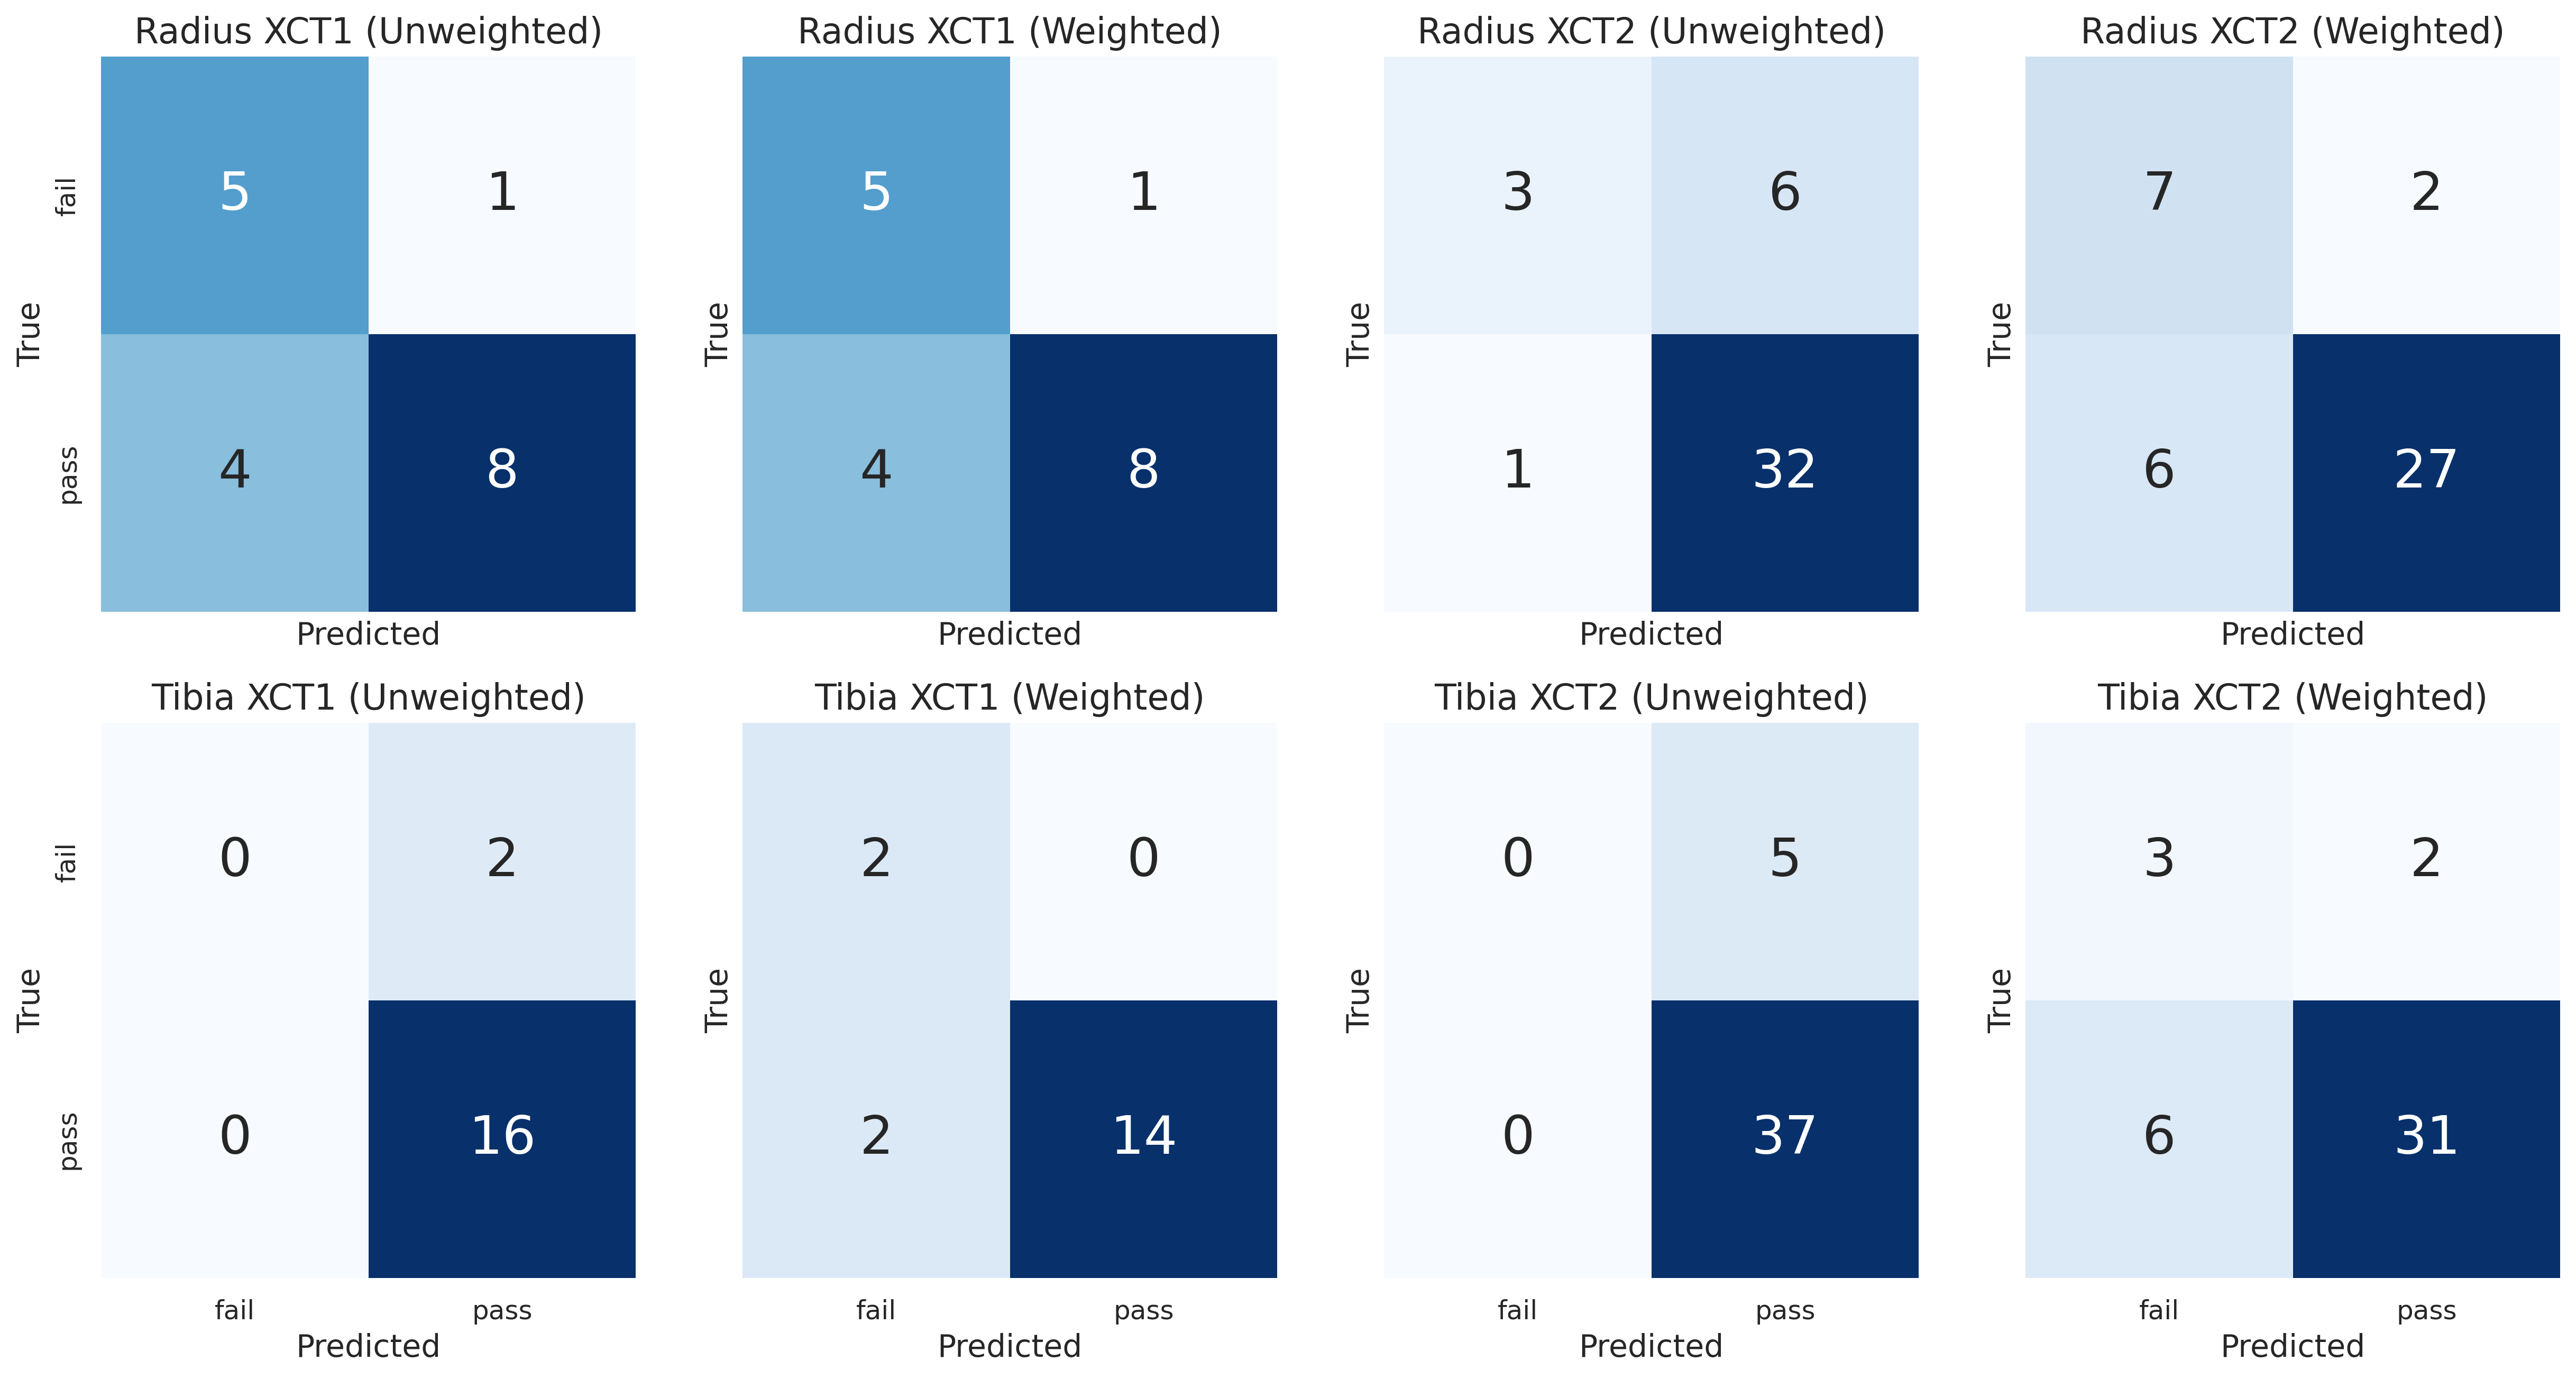

In [ ]:
# plot confusion matrices for each model, bone, and xct in a grid
sns.set(font_scale=2.0)
def plot_confusion_matrix(df, ax, title):
    all_labels = ['fail', 'pass']
    df['true'] = pd.Categorical(df['true'], categories=all_labels)
    df['pred'] = pd.Categorical(df['pred'], categories=all_labels)
    cm = pd.crosstab(df['true'], df['pred'], rownames=['True'], colnames=['Predicted'], margins=False, dropna=False)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False)
    ax.tick_params(axis='both', which='major', labelsize=12)
    ax.set_title(title, fontsize=16)
    ax.set_xlabel('Predicted', fontsize=14)
    ax.set_ylabel('True', fontsize=14)


fig, axes = plt.subplots(2, 4, figsize=(20, 10), dpi=300, sharex=True, sharey=True)
# use filtered_predictions to plot confusion matrices
for i, (model, group) in enumerate(filtered_predictions.groupby(['model', 'balanced'])):
    x_coord = i % 4
    y_coord = i // 4
    title = f"{model[0]} ({'Weighted' if model[1] else 'Unweighted'})"
    plot_confusion_matrix(group, axes[y_coord, x_coord], title)
